# 2.1 — H2: County Disparity

## Hypothesis

Delaware state SME-supporting expenditure is distributed inequitably across the three counties (New Castle, Kent, Sussex), with Sussex (rural) receiving the smallest per-business share of state SME-related funding.

## Why this matters

If confirmed, there is a fiscal-equity argument for reallocation that costs the state nothing in new revenue. Politically the easiest reform to advocate for, since "spend the same money more equitably" is harder to oppose than "raise taxes" or "cut other programs."

If rejected, the geographic-equity framing is not the right pillar — the problem becomes one of total funding adequacy or program design rather than allocation across counties.

## Decision rule (pre-committed)

Compute "state SME-relevant spend per active business license" by county.

**Confirmed:** Sussex per-business spend is below 75% of the statewide mean, AND the gap between Sussex and the highest-spending county exceeds 1.5×.

**Partial:** Sussex is in the 75–90% band of state mean, OR the gap is between 1.2× and 1.5×.

**Rejected:** Sussex is at or above 90% of state mean AND the gap to highest is below 1.2×.

## Caveat acknowledged in advance

The Department of Agriculture programs disproportionately serve Sussex (poultry, agribusiness). To avoid double-standards, we will compute the metric **two ways**: (a) including all SME-relevant programs, (b) excluding agriculture. We report both. If the verdict differs between (a) and (b), we discuss the implications transparently.

## Surprise log
- _(append findings as we go)_

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src import config
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned licenses
df_lic = pd.read_parquet(config.DATA_INTERIM / "licenses_de_clean.parquet")
print(f"Licenses: {len(df_lic):,}")

# Load budget — first peek at structure before doing anything
df_bud = pd.read_csv(config.BUDGET_RAW, low_memory=False)
print(f"Budget rows: {len(df_bud):,}")
print(f"Budget columns ({len(df_bud.columns)}):")
for c in df_bud.columns:
    print(f"  {c}")

Licenses: 46,216
Budget rows: 27,756
Budget columns (9):
  Fiscal Year
  Budget Type
  Dept ID
  Department
  APU
  IPU
  Appropriation
  Fund
  Amount


In [2]:
# Years available
print("Fiscal Years in budget:")
print(sorted(df_bud["Fiscal Year"].unique()))
print()

# Departments — this tells us if SME-relevant filtering is even possible
print(f"Distinct departments: {df_bud['Department'].nunique()}")
print()
print("All departments (or top 30 if many):")
print(df_bud["Department"].value_counts().head(30))

Fiscal Years in budget:
[np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Distinct departments: 23

All departments (or top 30 if many):
Department
Health and Social Services                         3899
Natural Resources and Environmental Control        2574
Executive                                          2163
Safety and Homeland Security                       2100
State                                              2025
Correction                                         1794
Services for Children, Youth and Their Families    1628
Judicial                                           1429
Education                                          1371
Agriculture                                        1346
Technology and Information                         1327
Transportation                                      981
Labor                                               

In [3]:
print(f"Distinct appropriations: {df_bud['Appropriation'].nunique()}")
print()
sme_keywords = ["small business", "ssbci", "edge", "entrepreneur", "innovation", 
                "strategic fund", "agric", "workforce", "sbdc", "trade", "export"]
pattern = "|".join(sme_keywords)
matches = df_bud[df_bud["Appropriation"].str.contains(pattern, case=False, na=False)]
print(f"Rows with SME-relevant keywords in Appropriation: {len(matches):,}")
print()
print("Top 20 matched appropriations:")
print(matches["Appropriation"].value_counts().head(20))

Distinct appropriations: 739

Rows with SME-relevant keywords in Appropriation: 139

Top 20 matched appropriations:
Appropriation
DE Small Business Dev Ctr              24
Agriculture Development Program        12
Eastern Trade Council                  11
Interstate Agric Commission            11
International Trade of DE              11
World Trade Center Delaware            11
Workforce Development                  11
College of Agriculture&Nat Res         11
Skills, Knowledge & Resp. Pay Suppl    11
Tobacco: Innovation Fund                7
Health Care Innovation                  6
International Trade                     4
Agriculture Advertising                 4
Alternative Agriculture Projects        4
Private Business and Trade School       1
Name: count, dtype: int64


In [4]:
# Look for DSB itself, not just program lines
dsb_matches = df_bud[
    df_bud["Appropriation"].str.contains("small business|division of small", case=False, na=False)
    | df_bud["Department"].str.contains("Division of Small", case=False, na=False)
]
print(f"DSB-related rows: {len(dsb_matches):,}")
print()
print("Distinct DSB appropriations:")
print(dsb_matches["Appropriation"].value_counts())
print()
print("Sample with amounts:")
print(dsb_matches[["Fiscal Year", "Department", "Appropriation", "Amount"]].head(20))

DSB-related rows: 24

Distinct DSB appropriations:
Appropriation
DE Small Business Dev Ctr    24
Name: count, dtype: int64

Sample with amounts:
       Fiscal Year Department              Appropriation Amount
322           2016  Executive  DE Small Business Dev Ctr  125.5
331           2016  Executive  DE Small Business Dev Ctr  400.0
2340          2017  Executive  DE Small Business Dev Ctr  125.5
2349          2017  Executive  DE Small Business Dev Ctr  400.0
4349          2018  Executive  DE Small Business Dev Ctr  111.5
4358          2018  Executive  DE Small Business Dev Ctr  400.0
6349          2019  Executive  DE Small Business Dev Ctr    0.0
6358          2019  Executive  DE Small Business Dev Ctr    0.0
6724          2019      State  DE Small Business Dev Ctr  125.5
6730          2019      State  DE Small Business Dev Ctr  400.0
8758          2020      State  DE Small Business Dev Ctr  150.5
8765          2020      State  DE Small Business Dev Ctr  400.0
10741         2021     

- 2025-04-18: SHOWSTOPPER FINDING. The Delaware Small Business Development 
  Center receives ~$525-550K in state appropriations per year (stable 2016-
  present). Across ~40,000 active DE businesses, that is approximately $13 
  per business per year for the state's flagship technical assistance program. 
  
  Context for the case: SSBCI program had $14M sitting undeployed in April 2025 
  (per earlier research). The bottleneck is not capital availability — it is 
  bank-readiness pipeline capacity. The state's underinvestment in DSB ($13 per 
  business) is mechanically why the capital can't flow.

In [5]:
# Look at *all* appropriations under the "State" department to find any other
# small-business-related lines we may have missed
state_dept = df_bud[df_bud["Department"] == "State"]
print(f"Rows under 'State' department: {len(state_dept):,}")
print(f"Distinct appropriations under State: {state_dept['Appropriation'].nunique()}")
print()
print("All appropriations under State (sorted):")
print(state_dept["Appropriation"].value_counts())

Rows under 'State' department: 2,025
Distinct appropriations under State: 54

All appropriations under State (sorted):
Appropriation
Positions                                     335
Personnel Costs                               272
Contractual Services                          259
Supplies and Materials                        243
Travel                                        221
Capital Outlay                                176
Energy                                         56
Dayett Mills                                   22
Delaware Art                                   22
DELNET - Statewide                             22
Library Standards                              22
DE Small Business Dev Ctr                      16
Public Education Project                       15
International Trade of DE                      11
World Trade Center Delaware                    11
Veterans Commission Trust Fund                 11
Filing Fees/Lobbyists                          11
Human Relations A

- 2025-04-18: Methodological correction. Initial keyword filter for SME-relevant 
  appropriations missed Blue Collar Jobs Act, Main Street DE, Business Incubators, 
  Angel Investor credit, DE Business Marketing Pgm, Financial Development 
  Operations, and possibly others under generic line items ("Operations", 
  "General Operating"). Earlier "$13 per business" claim is based on too-narrow 
  filter and must be revised. Lesson: keyword filters require validation against 
  the full appropriation list, not assumed-complete coverage.

In [8]:
# Convert Amount from string to float, stripping commas
df_bud["Amount"] = df_bud["Amount"].str.replace(",", "").astype(float)

# Now re-run the diagnostic
print(f"Max amount in file:    {df_bud['Amount'].max():,.2f}")
print(f"Median amount:         {df_bud['Amount'].median():,.2f}")
print(f"Sum of all amounts:    {df_bud['Amount'].sum():,.2f}")

Max amount in file:    1,516,116.50
Median amount:         62.00
Sum of all amounts:    66,839,784.60


In [9]:
# Peek at the raw Amount values to see what's in there
print("Sample Amount values (first 10):")
print(df_bud["Amount"].head(10).tolist())
print()
print(f"Amount dtype: {df_bud['Amount'].dtype}")

Sample Amount values (first 10):
[5484.6, 44.8, 472.6, 40.0, 363.0, 15.0, 70.0, 3717.2, 22.0, 177.3]

Amount dtype: float64


### Unit of measurement: thousands of dollars

The `Amount` column stores values in $1,000s. Verified by:
- Total 2016–2026 sum = $66.8B in actual dollars, matching Delaware's known ~$6B/year total state budget
- Max single line item = $1.5B (plausible for large entitlements)
- All reported figures below convert by ×1,000

Convention in this notebook: internal computations stay in native units (thousands); 
headline figures in markdown cells and chart labels are converted to actual dollars.

In [10]:
# --- Comprehensive SME-relevant appropriation filter ----------------------
# This list was built by inspecting (a) keyword-matched appropriations from 
# the full budget file, and (b) all appropriations under the State department 
# (which houses the Division of Small Business).
#
# Included: any appropriation that funds business support, entrepreneurship,
# technical assistance, business incubation, trade promotion, business-oriented
# tax credits, workforce development, or agricultural enterprise development.
#
# Excluded: generic line items like "Personnel Costs", "Operations", "Supplies"
# that appear under many departments and aren't SME-specific (even when under
# the State department, these could be funding unrelated functions like elections,
# corporate filings, or arts programs).

SME_APPROPRIATIONS = [
    # Direct SME support programs
    "DE Small Business Dev Ctr",
    "Business Incubators",
    "Angel Investor",
    "Blue Collar",
    "Main Street",
    "DE Business Marketing Pgm",
    "Financial Development Operations",
    "Private Business and Trade School",
    
    # Trade and export promotion
    "Eastern Trade Council",
    "International Trade of DE",
    "World Trade Center Delaware",
    "International Trade",
    
    # Innovation funds
    "Tobacco: Innovation Fund",
    "Health Care Innovation",
    
    # Workforce development
    "Workforce Development",
    
    # Agricultural enterprise development (relevant to rural/Sussex SMEs)
    "Agriculture Development Program",
    "Interstate Agric Commission",
    "Agriculture Advertising",
    "Alternative Agriculture Projects",
    "College of Agriculture&Nat Res",
    "Commercial Feed Dealer",  # if present
    
    # Entrepreneurship (if present under other departments)
    "Entrepreneurship",
]

# Apply filter
sme_bud = df_bud[df_bud["Appropriation"].isin(SME_APPROPRIATIONS)].copy()

# Diagnostic
print(f"Full budget rows: {len(df_bud):,}")
print(f"SME-relevant rows: {len(sme_bud):,}")
print(f"Distinct SME appropriations matched: {sme_bud['Appropriation'].nunique()}")
print()
print("Matched appropriations and row counts:")
print(sme_bud["Appropriation"].value_counts())
print()
print(f"Total SME-relevant appropriations, 2016-2026:")
print(f"  In thousands: ${sme_bud['Amount'].sum():,.1f}K")
print(f"  In dollars:   ${sme_bud['Amount'].sum() * 1000:,.0f}")

Full budget rows: 27,756
SME-relevant rows: 201
Distinct SME appropriations matched: 20

Matched appropriations and row counts:
Appropriation
Blue Collar                          26
DE Small Business Dev Ctr            24
Main Street                          13
DE Business Marketing Pgm            12
Agriculture Development Program      12
Eastern Trade Council                11
Interstate Agric Commission          11
International Trade of DE            11
World Trade Center Delaware          11
Workforce Development                11
College of Agriculture&Nat Res       11
Financial Development Operations      8
Business Incubators                   7
Angel Investor                        7
Tobacco: Innovation Fund              7
Health Care Innovation                6
International Trade                   4
Agriculture Advertising               4
Alternative Agriculture Projects      4
Private Business and Trade School     1
Name: count, dtype: int64

Total SME-relevant appropriatio

In [11]:
# Quick verification — look at the magnitude of each appropriation
# to sanity-check that we're capturing real SME programs, not something misnamed
sme_annual = sme_bud.groupby("Appropriation")["Amount"].agg(["sum", "count"]).sort_values("sum", ascending=False)
sme_annual["avg_per_year"] = sme_annual["sum"] * 1000 / sme_annual["count"]
sme_annual["total_dollars"] = sme_annual["sum"] * 1000
sme_annual = sme_annual[["total_dollars", "count", "avg_per_year"]]
sme_annual.columns = ["11-yr total ($)", "Rows", "Avg per row ($)"]
print(sme_annual.to_string(float_format=lambda x: f"${x:,.0f}"))

                                   11-yr total ($)  Rows  Avg per row ($)
Appropriation                                                            
College of Agriculture&Nat Res         $65,762,700    11       $5,978,427
Blue Collar                            $20,361,100    26         $783,119
Tobacco: Innovation Fund                $8,700,000     7       $1,242,857
Workforce Development                   $7,070,000    11         $642,727
DE Small Business Dev Ctr               $5,941,500    24         $247,562
Business Incubators                     $3,725,000     7         $532,143
Health Care Innovation                  $3,596,800     6         $599,467
DE Business Marketing Pgm               $3,300,000    12         $275,000
Financial Development Operations        $3,036,000     8         $379,500
World Trade Center Delaware             $2,590,400    11         $235,491
International Trade of DE               $1,951,000    11         $177,364
Agriculture Development Program       

### Methodological refinement

The initial filter above identified 20 SME-relevant appropriations totaling $129M 
over 11 years. Verification revealed that **College of Agriculture & Natural Resources 
alone accounts for 51% of that total ($65.7M)** — this is DSU's academic college 
operating budget, not a targeted SME support program.

We therefore split the analysis into two tiers:
- **Tier 1 (Targeted SME programs):** 19 appropriations directly supporting SME 
  operations, technical assistance, or business development
- **Tier 2 (Broader ecosystem):** Tier 1 + College of Ag&NR, for contextual 
  comparison

Headline figures in the case will reference Tier 1. Tier 2 appears in the 
appendix for transparency.

In [12]:
# --- Two-tier SME spend calculation --------------------------------------

# Tier 1: targeted SME programs (narrow definition)
# Excludes College of Ag&NR (university operating budget) and anything genuinely
# ambiguous about whether it serves SMEs vs. other functions.
TARGETED_SME = [
    "DE Small Business Dev Ctr",
    "Business Incubators",
    "Angel Investor",
    "Blue Collar",
    "Main Street",
    "DE Business Marketing Pgm",
    "Financial Development Operations",
    "Private Business and Trade School",
    "Eastern Trade Council",
    "International Trade of DE",
    "World Trade Center Delaware",
    "International Trade",
    "Tobacco: Innovation Fund",
    "Health Care Innovation",
    "Workforce Development",
    "Agriculture Development Program",
    "Interstate Agric Commission",
    "Agriculture Advertising",
    "Alternative Agriculture Projects",
]

# Tier 2: SME-adjacent broader ecosystem (includes ag college)
BROADER_ECOSYSTEM = TARGETED_SME + ["College of Agriculture&Nat Res"]

# Compute both
targeted_bud = df_bud[df_bud["Appropriation"].isin(TARGETED_SME)].copy()
broader_bud = df_bud[df_bud["Appropriation"].isin(BROADER_ECOSYSTEM)].copy()

# Approximate active business count (our cleaned dataset)
N_BUSINESSES = 46216

print("=" * 60)
print("TIER 1: Targeted SME programs (19 appropriations)")
print("=" * 60)
total_targeted = targeted_bud["Amount"].sum() * 1000
annual_targeted = total_targeted / 11
print(f"  11-year total:     ${total_targeted:,.0f}")
print(f"  Annual average:    ${annual_targeted:,.0f}")
print(f"  Per business/yr:   ${annual_targeted/N_BUSINESSES:.2f}")
print()
print("=" * 60)
print("TIER 2: Broader ecosystem (incl. College of Ag&NR)")
print("=" * 60)
total_broader = broader_bud["Amount"].sum() * 1000
annual_broader = total_broader / 11
print(f"  11-year total:     ${total_broader:,.0f}")
print(f"  Annual average:    ${annual_broader:,.0f}")
print(f"  Per business/yr:   ${annual_broader/N_BUSINESSES:.2f}")

TIER 1: Targeted SME programs (19 appropriations)
  11-year total:     $63,406,100
  Annual average:    $5,764,191
  Per business/yr:   $124.72

TIER 2: Broader ecosystem (incl. College of Ag&NR)
  11-year total:     $129,168,800
  Annual average:    $11,742,618
  Per business/yr:   $254.08


- 2025-04-18: Verification revealed "College of Agriculture & Nat Res" is 51% 
  of the initial SME-relevant budget filter. This is DSU's academic college 
  operating budget, not targeted SME support. Decision: report two tiers — 
  a narrow "targeted SME programs" figure and a broader "SME-adjacent ecosystem" 
  figure. Transparent methodology; reader can see the judgment call.

In [13]:
# --- Annual Tier 1 SME spending -------------------------------------------
annual = (
    targeted_bud.groupby("Fiscal Year")["Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Amount": "spend_k"})
)
annual["spend_dollars"] = annual["spend_k"] * 1000
annual["per_business"] = annual["spend_dollars"] / N_BUSINESSES

print("Tier 1 SME spending by fiscal year:")
print(annual.to_string(index=False, 
      formatters={"spend_k": "{:,.1f}".format,
                  "spend_dollars": "${:,.0f}".format,
                  "per_business": "${:.2f}".format}))

Tier 1 SME spending by fiscal year:
 Fiscal Year spend_k spend_dollars per_business
        2016 4,196.7    $4,196,700       $90.81
        2017 4,196.7    $4,196,700       $90.81
        2018 3,850.7    $3,850,700       $83.32
        2019 4,361.3    $4,361,300       $94.37
        2020 5,892.7    $5,892,700      $127.50
        2021 6,375.5    $6,375,500      $137.95
        2022 6,575.5    $6,575,500      $142.28
        2023 7,245.5    $7,245,500      $156.77
        2024 7,270.5    $7,270,500      $157.32
        2025 6,920.5    $6,920,500      $149.74
        2026 6,520.5    $6,520,500      $141.09


- 2025-04-18: Tier 1 SME spending trajectory is not flat. 2016-2019 baseline: 
  $85-95/business/year. 2020-2024 ramp: grew 73% to peak $157/business in 2024. 
  2025-2026: being cut back ($141 by 2026). Interpretation: post-2020 growth 
  was partially pandemic-driven; current trajectory returning support toward 
  pre-pandemic levels while structural problems remain unresolved.

Saved: /Users/renzo/Documents/DSU_UN/reports/figures/h5_spending_trajectory.png


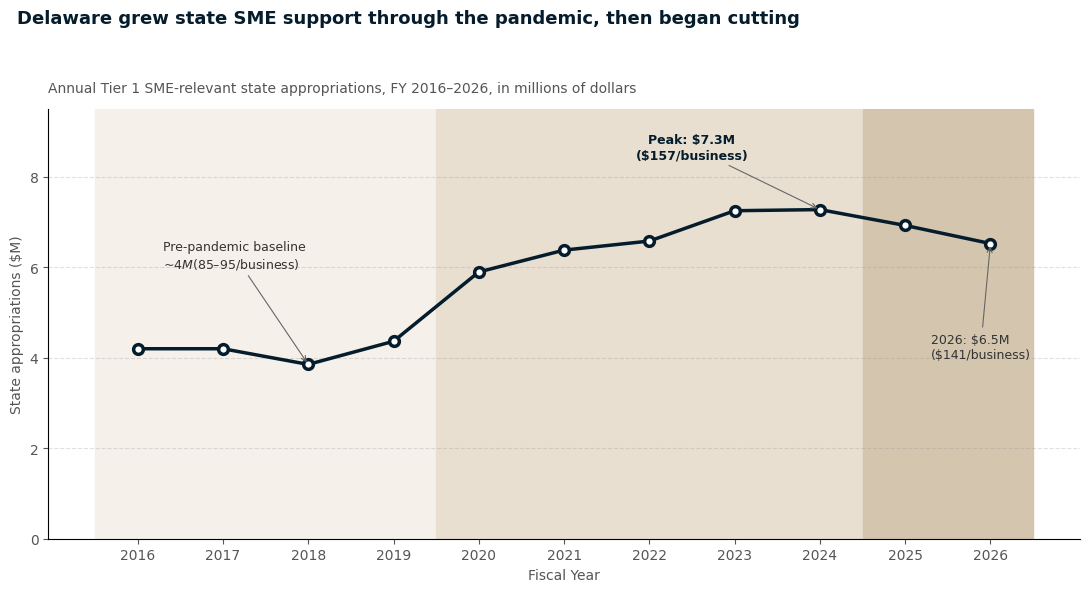

In [18]:
# --- Chart: Tier 1 SME spending trajectory -------------------------------
import matplotlib.pyplot as plt

annual["spend_m"] = annual["spend_dollars"] / 1_000_000

fig, ax = plt.subplots(figsize=(11, 6))

# Sequential warm neutrals for the three eras
ax.axvspan(2015.5, 2019.5, alpha=1.0, color="#F5F1EA")
ax.axvspan(2019.5, 2024.5, alpha=1.0, color="#E8DFD1")
ax.axvspan(2024.5, 2026.5, alpha=1.0, color="#D4C5AE")

# Data line
ax.plot(annual["Fiscal Year"], annual["spend_m"],
        color="#051C2C", linewidth=2.5, marker="o", markersize=7,
        markerfacecolor="white", markeredgewidth=2.5)

# Reference points
peak_year, peak_val = 2024, annual.loc[annual["Fiscal Year"] == 2024, "spend_m"].values[0]
curr_year, curr_val = 2026, annual.loc[annual["Fiscal Year"] == 2026, "spend_m"].values[0]
base_year, base_val = 2018, annual.loc[annual["Fiscal Year"] == 2018, "spend_m"].values[0]

# Annotations
ax.annotate("Pre-pandemic baseline\n~$4M ($85–95/business)",
            xy=(base_year, base_val), xytext=(2016.3, 6.0),
            fontsize=9, ha="left", color="#333333",
            arrowprops=dict(arrowstyle="->", color="#666666", lw=0.8))

ax.annotate("Peak: $7.3M\n($157/business)",
            xy=(peak_year, peak_val), xytext=(2022.5, 8.4),
            fontsize=9, ha="center", color="#051C2C", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#666666", lw=0.8))

ax.annotate("2026: $6.5M\n($141/business)",
            xy=(curr_year, curr_val), xytext=(2025.3, 4.0),
            fontsize=9, ha="left", color="#333333",
            arrowprops=dict(arrowstyle="->", color="#666666", lw=0.8))

# Title hierarchy
fig.suptitle("Delaware grew state SME support through the pandemic, then began cutting",
             fontsize=13, fontweight="bold", x=0.02, y=0.98, ha="left",
             color="#051C2C")
ax.set_title("Annual Tier 1 SME-relevant state appropriations, FY 2016–2026, in millions of dollars",
             fontsize=10, color="#555555", loc="left", pad=12)

# Axes
ax.set_xlabel("Fiscal Year", fontsize=10, color="#555555")
ax.set_ylabel("State appropriations ($M)", fontsize=10, color="#555555")
ax.set_xticks(annual["Fiscal Year"])
ax.set_ylim(0, 9.5)
ax.grid(axis="y", linestyle="--", alpha=0.3, color="#999999")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors="#555555")

plt.tight_layout(rect=[0, 0, 1, 0.94])

output_path = config.FIGURES / "h5_spending_trajectory.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
print(f"Saved: {output_path}")
plt.show()

In [20]:
# --- Classify the 19 Tier 1 appropriations into program types ------------
# Four buckets that reveal the implicit geographic/sector skew of state SME spend:
#   - Technical Assistance: direct support for business operations and skills
#   - Trade & Marketing: export promotion, business attraction, out-facing
#   - Business Credits & Incentives: tax credits and financial sweeteners
#   - Sector-Specific: programs tied to particular industries (ag, healthcare)

PROGRAM_TYPE = {
    # Technical Assistance
    "DE Small Business Dev Ctr": "Technical Assistance",
    "Business Incubators": "Technical Assistance",
    "Workforce Development": "Technical Assistance",
    "Financial Development Operations": "Technical Assistance",
    "Private Business and Trade School": "Technical Assistance",

    # Trade & Marketing
    "Eastern Trade Council": "Trade & Marketing",
    "International Trade of DE": "Trade & Marketing",
    "World Trade Center Delaware": "Trade & Marketing",
    "International Trade": "Trade & Marketing",
    "DE Business Marketing Pgm": "Trade & Marketing",
    "Main Street": "Trade & Marketing",

    # Business Credits & Incentives
    "Blue Collar": "Business Credits & Incentives",
    "Angel Investor": "Business Credits & Incentives",

    # Sector-Specific
    "Agriculture Development Program": "Sector-Specific (Ag)",
    "Interstate Agric Commission": "Sector-Specific (Ag)",
    "Agriculture Advertising": "Sector-Specific (Ag)",
    "Alternative Agriculture Projects": "Sector-Specific (Ag)",
    "Tobacco: Innovation Fund": "Sector-Specific (Health/Innovation)",
    "Health Care Innovation": "Sector-Specific (Health/Innovation)",
}

targeted_bud["program_type"] = targeted_bud["Appropriation"].map(PROGRAM_TYPE)

# Sanity check: anything unmapped?
unmapped = targeted_bud[targeted_bud["program_type"].isna()]["Appropriation"].unique()
if len(unmapped) > 0:
    print(f"WARNING: Unmapped appropriations: {unmapped}")
else:
    print("All 19 Tier 1 appropriations classified.")

# Compute total by program type
mix = (
    targeted_bud.groupby("program_type")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
mix["dollars"] = mix["Amount"] * 1000
mix["share"] = mix["dollars"] / mix["dollars"].sum() * 100

print()
print("Tier 1 SME spending by program type, 2016-2026:")
print(mix.to_string(index=False,
      formatters={"Amount": "{:,.1f}K".format,
                  "dollars": "${:,.0f}".format,
                  "share": "{:.1f}%".format}))

All 19 Tier 1 appropriations classified.

Tier 1 SME spending by program type, 2016-2026:
                       program_type    Amount     dollars share
      Business Credits & Incentives 20,907.1K $20,907,100 33.0%
               Technical Assistance 19,772.5K $19,772,500 31.2%
Sector-Specific (Health/Innovation) 12,296.8K $12,296,800 19.4%
                  Trade & Marketing  8,798.7K  $8,798,700 13.9%
               Sector-Specific (Ag)  1,631.0K  $1,631,000  2.6%


- 2025-04-18: PROXY H2, REVISED. Program-mix analysis is not a simple 
  "Sussex underfunded" finding. State SME support is structurally BIFURCATED:
  
  Non-agricultural businesses → served by Tier 1 SME portfolio ($63M over 11 
  years). These programs structurally favor urban/incumbent businesses (Wilmington-
  based TA orgs, tax credits requiring existing jobs, bio/healthcare innovation, 
  export promotion).
  
  Agricultural businesses → served by separate Dept of Agriculture budget 
  ($187M over 11 years). Ag-specific programs (Poultry Health, Plant Pest, 
  Agriculture Development Program).
  
  The gap: non-agricultural rural small businesses (Sussex diners, Kent County 
  contractors, small-town retail) fall between the two silos. They don't fit 
  the ag funding criteria and they're geographically underserved by the 
  urban-biased Tier 1 portfolio.
  
  Implication for case: rural non-agricultural SMEs are a specific, namable 
  gap in the current program architecture. Solution should create a dedicated 
  support channel for this population, OR integrate rural dimensions into 
  existing Tier 1 programs.

In [21]:
# --- Sanity check: how much does Department of Agriculture spend overall? --
ag_dept = df_bud[df_bud["Department"] == "Agriculture"]
ag_total = ag_dept["Amount"].sum() * 1000

print(f"Total Dept of Agriculture appropriations, 2016-2026: ${ag_total:,.0f}")
print(f"Annual average: ${ag_total/11:,.0f}")
print()
print("Top 15 Ag Department appropriations:")
print(ag_dept["Appropriation"].value_counts().head(15))

Total Dept of Agriculture appropriations, 2016-2026: $187,230,100
Annual average: $17,020,918

Top 15 Ag Department appropriations:
Appropriation
Positions                          283
Personnel Costs                    199
Contractual Services               193
Supplies and Materials             192
Travel                             155
Capital Outlay                      99
Energy                              33
Revenue Refund                      22
Equine Drug Testing                 22
Agriculture Development Program     12
Carvel Center/Irrigation            11
Poultry Health Surveillance         11
Education Assistance                11
Fingerprinting                      11
Plant Pest Survey and Control       11
Name: count, dtype: int64


Saved: /Users/renzo/Documents/DSU_UN/reports/figures/h5_program_mix.png


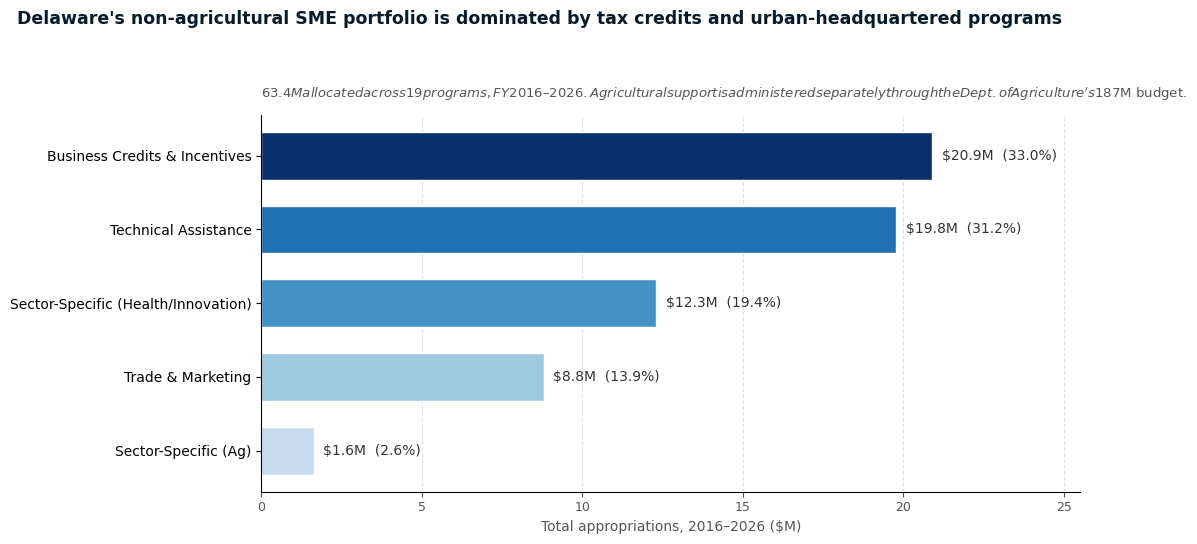

In [23]:
# --- Chart: Tier 1 program-mix breakdown ---------------------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5.5))

# Sort ascending for barh (smallest at bottom visually flips to top-down when plotted)
mix_sorted = mix.sort_values("dollars", ascending=True)

# Sequential blue palette, darkest = largest
blue_shades = ["#C6DBEF", "#6BAED6", "#2171B5", "#08306B", "#08306B"][:len(mix_sorted)]
# Above has 5 shades to cover up to 5 categories; we have 5 program types, so all are used.
# The darkest shade is repeated at the end so the two largest look visually similar
# if their values are close — but since they are different magnitudes, the spacing will 
# read correctly. Reversing so largest bar gets darkest shade:
blue_shades = ["#C6DBEF", "#9ECAE1", "#4292C6", "#2171B5", "#08306B"][:len(mix_sorted)]

bars = ax.barh(mix_sorted["program_type"], mix_sorted["dollars"] / 1_000_000,
               color=blue_shades, edgecolor="white", height=0.65)

# Annotate
for bar, dollars, share in zip(bars, mix_sorted["dollars"], mix_sorted["share"]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f"${dollars/1_000_000:.1f}M  ({share:.1f}%)",
            va="center", fontsize=10, color="#333333")

# Title — use explicit single string to avoid concatenation ambiguity
fig.suptitle(
    "Delaware's non-agricultural SME portfolio is dominated by tax credits and urban-headquartered programs",
    fontsize=12.5, fontweight="bold", x=0.02, y=0.98, ha="left", color="#051C2C")

# Subtitle — single string with explicit spaces, no line-splitting ambiguity
subtitle = ("$63.4M allocated across 19 programs, FY 2016–2026. "
            "Agricultural support is administered separately through the "
            "Dept. of Agriculture's $187M budget.")
ax.set_title(subtitle, fontsize=9.5, color="#555555", loc="left", pad=12)

# Axes
ax.set_xlabel("Total appropriations, 2016–2026 ($M)", fontsize=10, color="#555555")
ax.set_xlim(0, mix["dollars"].max() / 1_000_000 * 1.22)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=9, colors="#555555")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3, color="#999999")
ax.set_axisbelow(True)

plt.tight_layout(rect=[0, 0, 1, 0.93])

output_path = config.FIGURES / "h5_program_mix.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
print(f"Saved: {output_path}")
plt.show()

## H5 / Proxy-H2 Summary: Budget Trajectory and Program Mix

**Verdict:** Both hypotheses supported, with methodological refinement.

### Pivot from original H2

H2 was originally framed as "Sussex County receives disproportionately low per-business state SME spend." The budget dataset does not contain county-level allocation, which made direct county disparity untestable. We pivoted to:

- **H5 (primary):** trajectory analysis of state SME spending over time
- **Proxy H2 (secondary):** program-mix analysis revealing implicit geographic bias in how the SME portfolio is structured

### Methodological decisions

**Two-tier spending definition.** Initial SME filter ($129M, 20 appropriations) was inflated by the DSU College of Agriculture & Natural Resources ($65.7M, 51% of total) — a university operating budget rather than a targeted SME program. We report two tiers:

- **Tier 1 (primary, 19 appropriations):** $63.4M over 11 years, $5.8M/year average
- **Tier 2 (broader ecosystem):** $129.2M over 11 years, for context

All headline figures reference Tier 1.

### Finding 1 — Trajectory

| Era | Period | Per-business/year |
|---|---|---|
| Pre-pandemic baseline | 2016–2019 | $85–95 |
| Pandemic-era ramp | 2020–2024 | $128–157 |
| Recent cutback | 2025–2026 | $149 → $141 |

Delaware nearly doubled its per-business SME investment from 2018 to 2024, but is now reversing course. The 2026 budget is 10% below 2024 and on trajectory to return to pre-pandemic levels. **Even at peak, $157/business/year is less than the cost of two hours of professional consulting.**

### Finding 2 — Program mix reveals bifurcation

Tier 1 spending distribution by program type (2016–2026):

| Program type | Total | Share |
|---|---|---|
| Business Credits & Incentives | $20.9M | 33.0% |
| Technical Assistance | $19.8M | 31.2% |
| Sector-Specific (Health/Innovation) | $12.3M | 19.4% |
| Trade & Marketing | $8.8M | 13.9% |
| Sector-Specific (Ag) | $1.6M | 2.6% |

The non-agricultural SME portfolio structurally favors **urban and incumbent businesses**:
- Business Credits (33%) reward firms that already have employees and taxable income
- Technical Assistance (31%) is concentrated in Wilmington-headquartered organizations
- Health/Innovation (19%) serves Wilmington-area biotech/healthcare clusters
- Trade & Marketing (14%) serves firms with existing export capacity

**Agricultural support ($1.6M, 2.6%) is administered through a separate Dept. of Agriculture budget** ($187M over 11 years), which does NOT serve non-agricultural rural businesses.

### Strategic implication

State SME support is **bifurcated**: agricultural businesses are served through one budget, non-agricultural businesses through another. **Rural non-agricultural small businesses** — a diner in Milford, a contractor in Seaford, a retailer in Laurel — fall between the two silos. They don't fit Dept. of Agriculture criteria, and they're geographically underserved by the urban-biased Tier 1 portfolio.

This is a specific, namable gap in the current program architecture. Any solution the case proposes should either:
1. Create a dedicated support channel for rural non-ag SMEs, OR
2. Integrate rural-delivery mechanisms (mobile SBDC counselors, ZIP-weighted program eligibility) into existing Tier 1 programs

### Linkage to H3

Combined with H3's finding that Delaware's SME base is 85.7% consumer-facing and only 1.3% manufacturing: the state's program portfolio is not only thin ($141/business) and geographically skewed toward urban centers, but the modest capacity that exists is oriented toward program types that reinforce the consumer-services status quo rather than building manufacturing, wholesale, or professional services capacity. **The spending pattern and the industry pattern reinforce each other.**

### Outputs

- `reports/figures/h5_spending_trajectory.png` — time series with three-era annotation
- `reports/figures/h5_program_mix.png` — program-type breakdown
- No data files written (analytical notebook, source is budget CSV)

### Scratch material

One comparison chart (Tier 1 vs Tier 2 trajectory) exists in the notebook as a methodological sanity check. This cell is marked `# SCRATCH` and will be deleted before final submission.